# Ising Model & Phase Transition

## The Ising Model

The **Ising model** is the simplest non-trivial model in statistical physics exhibiting a **phase transition**. It consists of a lattice of binary spins $\sigma_i \in \{-1, +1\}$ with nearest-neighbor interactions governed by the Hamiltonian:
$$\mathcal{H}(\sigma) = -J \sum_{\langle i,j\rangle} \sigma_i \sigma_j - h \sum_i \sigma_i$$

where $J > 0$ is the **coupling constant** (ferromagnetic), $h$ is an external magnetic field, and $\langle i,j\rangle$ denotes nearest-neighbor pairs.

## Statistical Mechanics Formulation

At temperature $T$, the system follows the **Boltzmann distribution**:
$$P(\sigma) = \frac{1}{Z} \exp\left(-\frac{\mathcal{H}(\sigma)}{k_B T}\right)$$

The relevant parameter is the **reduced temperature** $\beta = J / (k_B T)$.

## Phase Transition

In 2D, Onsager (1944) showed analytically that the Ising model undergoes a **second-order phase transition** at the critical temperature:
$$T_c = \frac{2J}{k_B \ln(1+\sqrt{2})} \approx 2.269\, J/k_B$$

- For $T > T_c$: **disordered phase** — spins fluctuate randomly, net magnetization $\langle M \rangle = 0$
- For $T < T_c$: **ordered (ferromagnetic) phase** — spins align, $|\langle M \rangle| > 0$

## Metropolis Algorithm

We sample from the Boltzmann distribution using the **Metropolis–Hastings** algorithm:
1. Randomly select spin $i$
2. Compute energy change $\Delta E = 2 \sigma_i \sum_{j \sim i} \sigma_j$ for flipping
3. Accept flip with probability $\min(1, e^{-\Delta E / k_B T})$

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

### Metropolis update (vectorized)

For efficiency, we use a **checkerboard** (even/odd) update that allows vectorized parallel spin flips without conflicts.

In [2]:
Tc = 2.0 / np.log(1 + np.sqrt(2))  # Exact critical temperature (J=kB=1)

def neighbor_sum(S):
    """Sum of 4 nearest neighbors with periodic BC."""
    return (np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
            np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1))

def metropolis_sweep(S, T, rng):
    """One full sweep (N^2 updates) using checkerboard decomposition."""
    n = S.shape[0]
    for parity in [0, 1]:
        # Build checkerboard mask
        Y, X = np.mgrid[0:n, 0:n]
        mask = ((X + Y) % 2 == parity)
        h = neighbor_sum(S)
        delta_E = 2.0 * S * h
        accept = rng.uniform(size=S.shape) < np.exp(-delta_E / T)
        flip = mask & (delta_E > 0) | mask & (delta_E <= 0)
        flip = mask & accept | mask & (delta_E <= 0)
        S = np.where(flip, -S, S)
    return S

def run_ising(n=32, T=Tc, n_sweeps=200, seed=42):
    """Run Ising simulation from random initial state."""
    rng = np.random.default_rng(seed)
    S = rng.choice([-1, 1], size=(n, n)).astype(float)
    snapshots = []
    magnetizations = []
    for sweep in range(n_sweeps):
        S = metropolis_sweep(S, T, rng)
        if sweep % 10 == 0:
            snapshots.append(S.copy())
        magnetizations.append(abs(S.mean()))
    return S, snapshots, np.array(magnetizations)

print(f'Exact critical temperature: Tc = {Tc:.4f}')

Exact critical temperature: Tc = 2.2692


### Phase transition visualization

We run the Ising model at three temperatures: $T \ll T_c$ (ordered), $T = T_c$ (critical), and $T \gg T_c$ (disordered). At the critical temperature, **critical fluctuations** at all scales appear — the famous hallmark of a continuous phase transition.

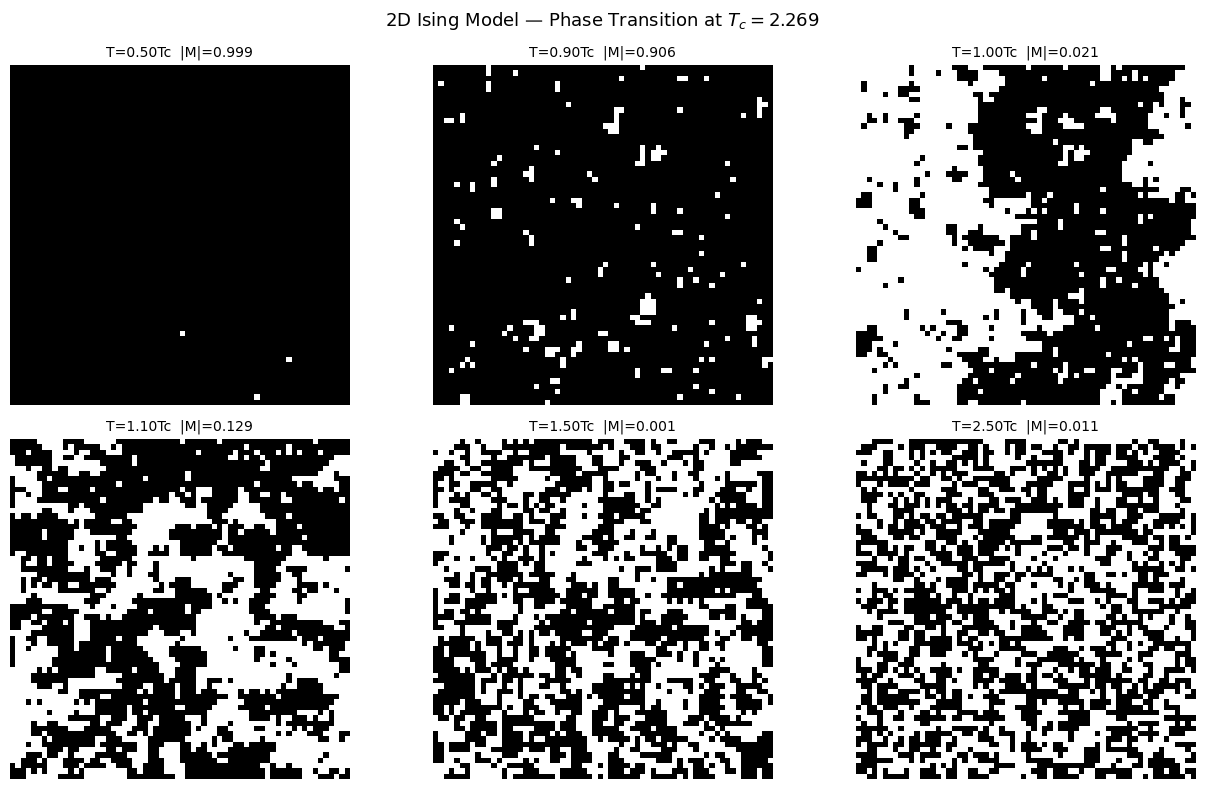

In [3]:
n_grid = 64
temperatures = [0.5 * Tc, 0.9 * Tc, Tc, 1.1 * Tc, 1.5 * Tc, 2.5 * Tc]
labels = [f'T={t/Tc:.2f}Tc' for t in temperatures]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, T, label in zip(axes.ravel(), temperatures, labels):
    S_final, _, _ = run_ising(n=n_grid, T=T, n_sweeps=300, seed=42)
    ax.imshow(S_final, cmap='gray', vmin=-1, vmax=1)
    M = abs(S_final.mean())
    ax.set_title(f'{label}  |M|={M:.3f}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'2D Ising Model — Phase Transition at $T_c = {Tc:.3f}$', fontsize=13)
plt.tight_layout(); plt.savefig('ising_phases.png', dpi=100, bbox_inches='tight'); plt.show()

### Magnetization curve

The **order parameter** is the mean magnetization $\langle |M| \rangle = |N^{-1} \sum_i \sigma_i|$. Near $T_c$ it vanishes as:
$$\langle |M| \rangle \sim (T_c - T)^\beta, \quad \beta = 1/8 \text{ (2D Ising)}$$

This is the Onsager result for the **critical exponent** $\beta$.

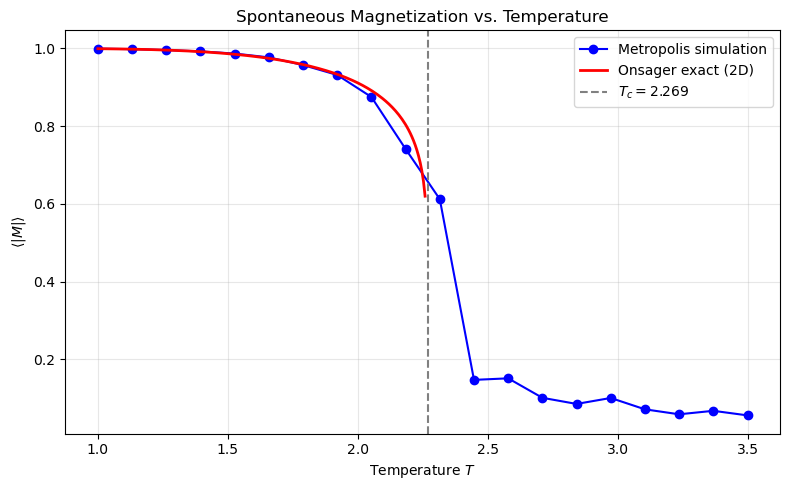

In [4]:
T_range = np.linspace(1.0, 3.5, 20)
avg_magnetizations = []

for T in T_range:
    _, _, mags = run_ising(n=32, T=T, n_sweeps=150, seed=7)
    avg_magnetizations.append(mags[-50:].mean())  # average last 50 sweeps

# Onsager exact solution M = (1 - sinh(2J/T)^{-4})^{1/8}
T_exact = np.linspace(1.0, Tc - 0.01, 200)
M_exact = (1 - np.sinh(2.0 / T_exact)**(-4))**(1/8)

plt.figure(figsize=(8, 5))
plt.plot(T_range, avg_magnetizations, 'bo-', ms=6, label='Metropolis simulation')
plt.plot(T_exact, M_exact, 'r-', lw=2, label='Onsager exact (2D)')
plt.axvline(Tc, color='gray', linestyle='--', label=f'$T_c = {Tc:.3f}$')
plt.xlabel('Temperature $T$'); plt.ylabel('$\\langle |M| \\rangle$')
plt.title('Spontaneous Magnetization vs. Temperature')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ising_magnetization.png', dpi=100, bbox_inches='tight'); plt.show()

### Temporal evolution at the critical point

At $T = T_c$, the system exhibits **critical slowing down**: the autocorrelation time diverges and the system takes extremely long to decorrelate. We show the spin evolution over many sweeps.

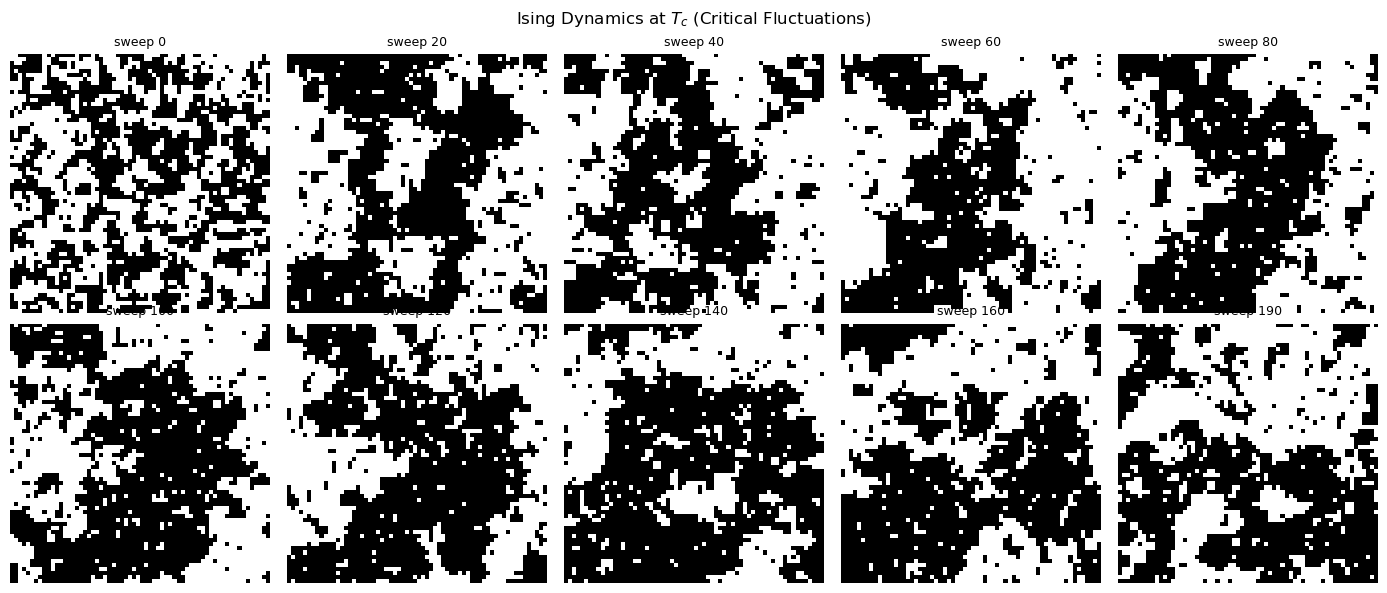

In [5]:
_, snaps_crit, mags_crit = run_ising(n=64, T=Tc, n_sweeps=200, seed=0)

snap_iters = [0, 2, 4, 6, 8, 10, 12, 14, 16, 19]
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.ravel(), snap_iters):
    ax.imshow(snaps_crit[min(i, len(snaps_crit)-1)], cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'sweep {i*10}', fontsize=9); ax.axis('off')
plt.suptitle(f'Ising Dynamics at $T_c$ (Critical Fluctuations)', fontsize=12)
plt.tight_layout(); plt.savefig('ising_dynamics.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: temperature control

In [ ]:
def show_ising(T_ratio=1.0):
    T = T_ratio * Tc
    S_f, snaps, mags = run_ising(n=48, T=T, n_sweeps=150, seed=3)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(S_f, cmap='gray', vmin=-1, vmax=1)
    axes[0].set_title(f'T = {T_ratio:.2f}·Tc  |M| = {abs(S_f.mean()):.3f}')
    axes[0].axis('off')
    axes[1].plot(mags, 'b-', lw=1.5)
    axes[1].set_xlabel('Sweep'); axes[1].set_ylabel('|Magnetization|')
    axes[1].set_ylim(0, 1); axes[1].set_title('Magnetization over time')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_ising,
         T_ratio=FloatSlider(min=0.3, max=3.0, step=0.1, value=1.0,
                              description='T/Tc'));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 3, figsize=(12, 8))
    for ax, T, label in zip(axes.ravel(), temperatures, labels):
        S_f, _, _ = run_ising(n=n_grid, T=T, n_sweeps=300, seed=42)
        ax.imshow(S_f, cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'{label}  |M|={abs(S_f.mean()):.3f}', fontsize=10)
        ax.axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The 2D Ising model is exactly solvable (Onsager 1944) and provides a paradigmatic example of a **continuous phase transition**.
- The critical temperature $T_c = 2J / \ln(1+\sqrt{2})$ separates the ordered and disordered phases.
- At $T_c$, the system exhibits scale-invariant critical fluctuations — spin clusters appear at all scales.
- The critical exponent $\beta = 1/8$ governs the vanishing of magnetization near $T_c$.

## Bibliography

- L. Onsager, *Crystal statistics I: A two-dimensional model with an order-disorder transition*, Phys. Rev. 65, 1944.
- N. Metropolis et al., *Equation of state calculations by fast computing machines*, J. Chem. Phys. 21, 1953.
- K. Huang, *Statistical Mechanics*, Wiley, 1987.